In [14]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.transforms
import numpy as np
import math
import pandas as pd
import os

Import Excel Data

In [15]:
file_name = 'Lab_1_PH424_Data.xlsx'

file_path = '/home/xspoole/PH424HW/Lab2PH424.xlsx'

try:
    df = pd.read_excel(file_path, engine='openpyxl')
    print(df.head()) # Print the first 5 rows to verify
except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found at {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

   Resistance (ohms)  Reflected Voltage (V)  Transmitted Voltage (V)  \
0               22.4                  -2.26                     1.32   
1               47.5                  -1.82                     2.60   
2               99.9                  -0.28                     3.64   
3              223.2                   0.96                     4.96   
4              466.0                   1.40                     5.92   

   Incident Voltage (V)  reflect_amp  reflect_volt  
0                  4.72    -0.478814      0.279661  
1                  4.68    -0.388889      0.555556  
2                  4.72    -0.059322      0.771186  
3                  4.72     0.203390      1.050847  
4                  4.52     0.309735      1.309735  


Reflected Graph

In [16]:
def undampRTheory(x):
    numerator = x - 93
    denominator = x + 93
    R = numerator/denominator
    return R

resistance = np.linspace(0, 2500, 5000)
amplitude = undampRTheory(resistance)

In [17]:
def dampRTheory(x):
    gamma = -(0.03*300)/(2*93)
    damp = np.e**gamma
    numerator = x - 93
    denominator = x + 93
    R = damp*numerator/denominator
    return R

dampresistance = np.linspace(0, 2500, 5000)
dampamplitude = dampRTheory(dampresistance)

In [18]:
def dampRTheoryAdjust(x):
    damp = np.e**(-0.003*300)
    numerator = x - 93
    denominator = x + 93
    R = damp*numerator/denominator
    return R

dampadjresistance = np.linspace(0, 2500, 5000)
dampadjamplitude = dampRTheoryAdjust(dampadjresistance)

In [19]:
x_axis = df['Resistance (ohms)']
y_axis = df['reflect_amp']

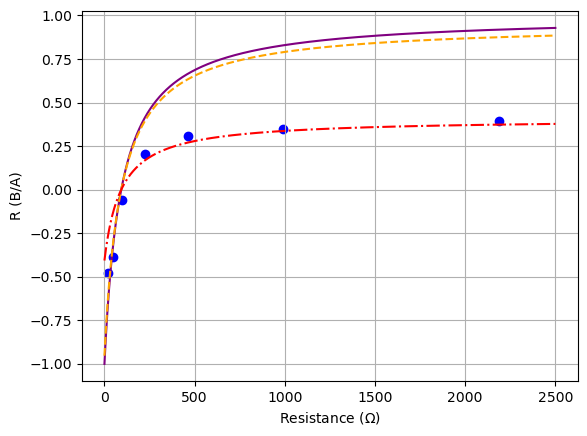

In [20]:
plt.plot(resistance, amplitude, color = 'purple')
plt.plot(dampresistance, dampamplitude, color = 'orange', ls = '--')
plt.plot(dampadjresistance, dampadjamplitude, color = 'red', ls = '-.')
plt.scatter(x_axis, y_axis, color = 'blue')
plt.grid(True)
plt.xlabel(r'Resistance ($\Omega$)')
plt.ylabel('R (B/A)')

plt.savefig('../reflect.png')

Transmitted Graph

In [21]:
def undampTTheory(x):
    numerator = 2*x
    denominator = x + 93
    T = numerator/denominator
    return T

resistance = np.linspace(0, 2500, 5000)
amplitude = undampTTheory(resistance)

In [22]:
def dampTTheory(x):
    gamma = -(0.03*150)/(2*93)
    damp = np.e**gamma
    numerator = 2*x
    denominator = x + 93
    T = damp*numerator/denominator
    return T

dampresistance = np.linspace(0, 2500, 5000)
dampamplitude = dampTTheory(resistance)

In [23]:
def dampTTheoryAdjust(x):
    gamma = -0.0012*150
    damp = np.e**gamma
    numerator = 2*x
    denominator = x + 93
    T = damp*numerator/denominator
    return T

dampadjresistance = np.linspace(0, 2500, 5000)
dampadjamplitude = dampTTheoryAdjust(resistance)

In [24]:
x_axis = df['Resistance (ohms)']
y_axis = df['reflect_volt']

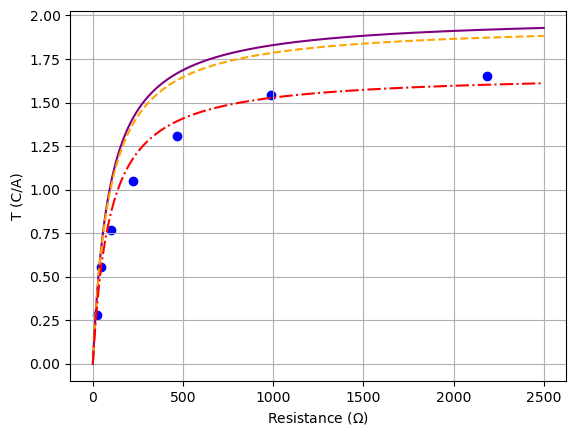

In [25]:
plt.plot(resistance, amplitude, color = 'purple')
plt.plot(dampresistance, dampamplitude, color = 'orange', ls = '--')
plt.plot(dampadjresistance, dampadjamplitude, color = 'red', ls = '-.')
plt.scatter(x_axis, y_axis, color = 'blue')
plt.grid(True)
plt.xlabel(r'Resistance ($\Omega$)')
plt.ylabel('T (C/A)')

plt.savefig('../transmit.png')